<a href="https://colab.research.google.com/github/CodeSage54/Deep-Learning/blob/main/Transfer%20Learning/TransferLearning_Using_VGG16_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Learning from Pre-Built Models**

***Problem Statement:*** The categorization of images into distinct classes is a pervasive task in computer vision, and it has a wide array of applications, including in pet identification and animal monitoring systems. In this assignment, we aim to develop a model capable of accurately distinguishing between cat and dog images. Instead of building a convolutional neural network (CNN) from scratch, we will leverage transfer learning using the VGG16 model, a pre-trained model on the ImageNet dataset. VGG16 is renowned for its effectiveness in image recognition tasks, but it does not have broad categories for cats and dogs. Therefore, we will utilize the convolutional (Conv) layers of VGG16 for feature extraction and add custom fully connected (Cat) layers for the classification task.



***Objectives:***


**Utilize VGG16 for Feature Extraction:**

● Employ the VGG16 model, excluding its top layers, to serve as a feature extractor for cat and dog images.

● Ensure the input images are of the correct size (150x150) and preprocessed appropriately to match VGG16’s requirements.

**Data Preprocessing and Augmentation:** Implement image data generators for real-time data augmentation, ensuring a robust and varied dataset for training the classification layers.

**Build and Train the Classification Model:**

● Add custom fully connected layers on top of the VGG16 model for the classification task.

● Freeze the convolutional layers of VGG16 to retain the pre-trained features and only train the added classification layers.


**Model Compilation and Training:**

● Compile the model using stochastic gradient descent, categorical cross-entropy as the loss function, and accuracy as the evaluation metric
Train the model using the training data, and validate its performance using a validation set.



**Evaluate and Test the Model:**

● Assess the model’s performance based on its accuracy in classifying images into cat or dog categories. ● Implement a prediction function to classify new images, providing the predicted category and the associated confidence level


In [27]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt

In [14]:
# vgg16 model is a CNN model that contains 16 layers trained on Imagenet images. 13 convolutions layers and 3 fully connected layers at the top.
# We have to retain the training and weights of the inner CNN layers and train only the top dense layers to recognize cats vs dogs.
# vgg16 takes an image size of 224*224 but allows smaller dimensions for faster training if include_top=False
vgg_base = VGG16(weights='imagenet',
                 include_top=False, # removes the fully connected layers at the top (we’ll add our own).
                 input_shape=(150, 150, 3))

# Freeze convolutional layers. We are not going to retrain them.
for layer in vgg_base.layers:
    layer.trainable = False

In [15]:
# Load training and test (cat v dog) dataset from tensorflow.
# For the sake of simplicity, we would take cats vs dogs dataset available in TFDS to train instead of training from local drive images.
import tensorflow_datasets as tfds
import tensorflow as tf
# Here dataset is a tf.data.dataset object
dataset, info = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True)


In [16]:
# dataset is of type tf.data.dataset so you will have to check info variable to check how many samples are there.
print(info.splits['train'].num_examples)

# Dataset contains 23262 images.
# We will take a small sample of 250 cat and 250 dog images to do transferlearning on top of VGG16

23262


In [17]:
# Split into train, validation and test datasets
# We will just take 5000 images randomly for our experiment.
# But we should have equal images of cats and dogs in testing, validation and testing datasets to avoid class imbalance

# Separate cats (label=0) and dogs (label=1)
cats = dataset['train'].filter(lambda img, lbl: lbl == 0)
dogs = dataset['train'].filter(lambda img, lbl: lbl == 1)

# Take 500 cats and 500 dogs total
cats = cats.take(500)
dogs = dogs.take(500)

# --- Split into train/val/test with equal counts to avoid class imbalance---
# Train: 350 cats + 350 dogs
cats_train = cats.take(350)
dogs_train = dogs.take(350)

# Validation: 100 cats + 100 dogs
cats_val = cats.skip(350).take(100)
dogs_val = dogs.skip(350).take(100)

# Test: 50 cats + 50 dogs
cats_test = cats.skip(450).take(50)
dogs_test = dogs.skip(450).take(50)


# Combine and shuffle
balanced_dataset = cats_sample.concatenate(dogs_sample)
balanced_dataset = balanced_dataset.shuffle(1000, seed=42)

# Split into train (70%), val (20%), test (10%)
train_size = 700
val_size   = 200
test_size  = 100

# Combine splits
train_dataset = cats_train.concatenate(dogs_train).shuffle(train_size, seed=42)
val_dataset   = cats_val.concatenate(dogs_val).shuffle(val_size, seed=42)
test_dataset  = cats_test.concatenate(dogs_test).shuffle(test_size, seed=42)




In [18]:
# delete main dataset to avoid too much memory utlization
del dataset

In [19]:
# Preprocessing for training (with augmentation)
def preprocess_train(image, label):
    image = tf.image.resize(image, (150, 150))
    image = tf.cast(image, tf.float32) / 255.0

    # Data Augmentation.
    # Every epoch might have a different version of the same image to prevent generalization.
    image = tf.image.random_flip_left_right(image)        # horizontal flip
    image = tf.image.random_brightness(image, max_delta=0.2)  # brightness
    image = tf.image.random_contrast(image, 0.8, 1.2)     # contrast

    label = tf.one_hot(label, depth=2)
    return image, label

# Preprocessing for validation/testing (no augmentation)
def preprocess_val(image, label):
    image = tf.image.resize(image, (150, 150))
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, depth=2)
    return image, label

# Apply to datasets
train_dataset = (train_dataset
                 .map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
                 #.shuffle(1000)
                 .batch(16)
                 .prefetch(tf.data.AUTOTUNE))

val_dataset = (val_dataset
               .map(preprocess_val, num_parallel_calls=tf.data.AUTOTUNE)
               .batch(16)
               .prefetch(tf.data.AUTOTUNE))

test_dataset = (test_dataset
                .map(preprocess_val, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(16)
                .prefetch(tf.data.AUTOTUNE))

In [20]:

# Build model
model = Sequential([
    vgg_base,
    Flatten(),                        # flatten feature maps into 1D vector
    Dense(256, activation='relu'),    # fully connected layer
    Dropout(0.5),                     # regularization
    Dense(2, activation='softmax')    # output layer (2 classes: cat, dog)
])


In [21]:
model.compile(optimizer=SGD(learning_rate=0.001, momentum=0.9),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [22]:
# Train the model
history = model.fit(
    train_dataset,
    epochs=8,   # train for 8 epochs
    #steps_per_epoch=218,
    validation_data=val_dataset,
    #validation_steps=62,
    verbose=1
)

Epoch 1/8
     44/Unknown 7s 86ms/step - accuracy: 0.4962 - loss: 0.7688

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - accuracy: 0.4990 - loss: 0.7661 - val_accuracy: 0.8650 - val_loss: 0.4020
Epoch 2/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.7799 - loss: 0.4625 - val_accuracy: 0.8500 - val_loss: 0.3597
Epoch 3/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.7919 - loss: 0.4054 - val_accuracy: 0.8500 - val_loss: 0.3552
Epoch 4/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.8146 - loss: 0.3863 - val_accuracy: 0.8700 - val_loss: 0.3249
Epoch 5/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.8361 - loss: 0.3261 - val_accuracy: 0.8750 - val_loss: 0.3163
Epoch 6/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.8535 - loss: 0.3134 - val_accuracy: 0.9050 - val_loss: 0.2731
Epoch 7/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.8732 - loss: 0.2944 - val_accuracy: 0.8700 - val_loss: 0.3075
Epoch 8/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.8933 - loss: 0.2940 - val_accuracy: 0.8500 - val_loss:

In [12]:
# Model Performance metrics

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Evaluate loss and accuracy directly
test_loss, test_acc = model.evaluate(test_dataset, verbose=1)
print(f"Test Accuracy: {test_acc:.3f}, Test Loss: {test_loss:.3f}")

# Collect predictions and true labels
y_true, y_pred = [], []
for images, labels in test_dataset:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Classification report
print(classification_report(y_true, y_pred, target_names=["Cat", "Dog"]))

# Confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 487ms/step - accuracy: 0.8000 - loss: 0.4397
Test Accuracy: 0.800, Test Loss: 0.426
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 830ms/step
              precision    recall  f1-score   support

         Cat       0.97      0.69      0.81        52
         Dog       0.75      0.98      0.85        48

    accuracy                           0.83       100
   macro avg       0.86      0.84      0.83       100
weighted avg       0.86      0.83      0.83       100

Confusion Matrix:
 [[36 16]
 [ 1 47]]


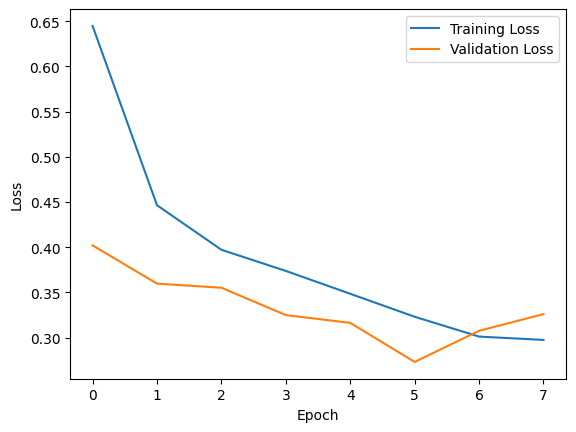

In [38]:
# Plot validation loss versus training loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [36]:
# Method to predict image labels of images uploaded from local machine
def predict_image(model, img_path):
    """
    Predict whether the given image is a Cat or Dog.

    Args:
        model: Trained Keras model
        img_path: Path to local image file (e.g., "my_cat.jpg")

    Returns:
        Predicted class index and confidence scores
    """
    # Load and preprocess image
    img = tf.keras.utils.load_img(img_path, target_size=(150, 150))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # add batch dimension
    img_array = img_array / 255.0             # normalize

    # Predict
    preds = model.predict(img_array)
    class_idx = np.argmax(preds[0])
    class_names = ["Cat", "Dog"]

    print(f"\n=============== Image Path :: {img_path}============= ")
    print(f"Prediction: {class_names[class_idx]} "
          f"(confidence: {preds[0][class_idx]:.2f})")
    plt.figure(figsize=(1,1))
    plt.imshow(img)
    plt.show()
    return class_names[class_idx], preds[0]

Saving breed_abyssinian_cat.jpg to breed_abyssinian_cat (4).jpg
Saving C.jpg to C (4).jpg
Saving D.jpg to D (4).jpg
Saving DC.jpg to DC (4).jpg
Saving download.jpg to download (5).jpg
Uploaded file: breed_abyssinian_cat (4).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

=============== Image Path :: breed_abyssinian_cat (4).jpg============= 
Prediction: Cat (confidence: 0.99)


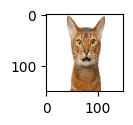

Uploaded file: C (4).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

=============== Image Path :: C (4).jpg============= 
Prediction: Cat (confidence: 1.00)


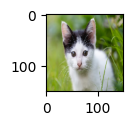

Uploaded file: D (4).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

=============== Image Path :: D (4).jpg============= 
Prediction: Dog (confidence: 1.00)


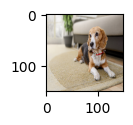

Uploaded file: DC (4).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

=============== Image Path :: DC (4).jpg============= 
Prediction: Dog (confidence: 0.99)


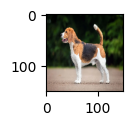

Uploaded file: download (5).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

=============== Image Path :: download (5).jpg============= 
Prediction: Cat (confidence: 0.58)


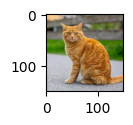

In [37]:
# Test the prediction with 5 images uploaded from local drive
from google.colab import files

# Step 1: Upload a file
uploaded = files.upload()

# Step 2: Get the filename
for filename in uploaded.keys():
    print("Uploaded file:", filename)

    # Step 3: Call predict_image on the uploaded file
    predict_image(model, filename)

**Summary:**


1.   VGG16 base model was extracted by excluding the top layers. The layers within the base model were marked as untrainable.
2. We added our own 2 dense layers on top of base vgg and trained the model on 500 Augmented images of cats and dogs coming from TensorFlow dataset.
3.   The model was tested for 8 EPOCHS and gave a good enough test accuracy of 80 percent.
4. It was also able to predict the images uploaded from local machine with a good confidence score.
5. Transfer learning saved a lot of time for us to train the 16 layer CNN on cats v dogs. We only trained the top layers on the new images leveraging the weights and biases of the pre-trained based model.

